In [13]:
import subprocess
import os

base_path = r"C:\Users\mique\OneDrive\Dokumenty\GitHub"

openface_path = rf"{base_path}\OpenFace_2.2.0_win_x64\FeatureExtraction.exe"

patient = "Patient_1"
quadrant = "Q1_2"

video_path = rf"D:\castphys_60\Data\{patient}\{quadrant}\vid_crop.avi"

output_dir = os.path.join(base_path, rf"POS\Gesture Emotion Prediction\Results\{patient}\{quadrant}")

os.makedirs(output_dir, exist_ok=True)

print("Video exists:", os.path.exists(video_path))
print("OpenFace exists:", os.path.exists(openface_path))
print("Output dir:", output_dir)


cmd = [
    openface_path,
    "-f", video_path,
    "-out_dir", output_dir,

    "-simscale", "0.25",
    "-feature_interval", "5",

    "-aus",
    "-nobadaligned"
]


#result = subprocess.run(cmd, capture_output=True, text=True)
result = subprocess.run(cmd)

print("Return code:", result.returncode)
print("STDOUT:\n", result.stdout)
print("STDERR:\n", result.stderr)

Video exists: True
OpenFace exists: True
Output dir: C:\Users\mique\OneDrive\Dokumenty\GitHub\POS\Gesture Emotion Prediction\Results\Patient_1\Q1_2
Return code: 0
STDOUT:
 None
STDERR:
 None


In [19]:
for f in os.listdir(output_dir):
    if f.endswith(".hog") or f.endswith(".txt") or f.endswith(".avi"):
        os.remove(os.path.join(output_dir, f))

In [1]:
quadrants = [
    "Q1_1",
    "Q1_2",
    "Q2_1",
    "Q2_2",
    "Q3_1",
    "Q3_2",
    "Q4_1",
    "Q4_2",
    "Q5_1",
    "Q5_2",
    "Q6_1",
    "Q6_2",
    "Q7_1",
    "Q7_2",
    "Q8_1",
    "Q8_2",
    "Q9_1",
    "Q9_2"
]

patients = list(range(1, 62))

patients.remove(23)

print(patients)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61]


In [ ]:
import pandas as pd
import os

base_path = r"C:\Users\mique\OneDrive\Dokumenty\GitHub"

"C:\Users\mique\OneDrive\Dokumenty\GitHubPOS\Gesture Emotion Prediction\Results\Patient_{patient}\{quadrant}\vid_crop.csv"

for patient in patients:
    for quadrant in quadrants:

        csv_path = os.path.join(base_path, rf"POS\Gesture Emotion Prediction\Results\Patient_{patient}\{quadrant}\vid_crop.csv")

        df = pd.read_csv(csv_path)

        # Remove leading/trailing spaces from column names
        df.columns = df.columns.str.strip()

        # Select only AU columns
        au_cols = [col for col in df.columns if col.startswith("AU")]
        df_aus = df[au_cols]

        print(df_aus.shape)

(1372, 35)
(1975, 35)
(2358, 35)
(1430, 35)
(1521, 35)
(3651, 35)
(2320, 35)
(1603, 35)
(1499, 35)
(1468, 35)
(5497, 35)
(2182, 35)
(3200, 35)
(3445, 35)
(1459, 35)
(1114, 35)
(2014, 35)
(1873, 35)
(1371, 35)
(1976, 35)
(2356, 35)
(1431, 35)
(1518, 35)
(3652, 35)
(2320, 35)
(1603, 35)
(1500, 35)
(1471, 35)
(5497, 35)
(2179, 35)
(3200, 35)
(3445, 35)
(1459, 35)
(1114, 35)
(2014, 35)
(1874, 35)
(1373, 35)
(1977, 35)
(2355, 35)
(1430, 35)
(1521, 35)
(3651, 35)
(2321, 35)
(1603, 35)
(1500, 35)
(1468, 35)
(5497, 35)
(2182, 35)
(3198, 35)
(3444, 35)
(1459, 35)
(1113, 35)
(2013, 35)
(1873, 35)
(1371, 35)
(1978, 35)
(2358, 35)
(1427, 35)
(1521, 35)
(3653, 35)
(2320, 35)
(1603, 35)
(1499, 35)
(1470, 35)
(5497, 35)
(2182, 35)
(3200, 35)
(3446, 35)
(1459, 35)
(1113, 35)
(2014, 35)
(1873, 35)
(1374, 35)
(1977, 35)
(2359, 35)
(1427, 35)
(1522, 35)
(3652, 35)
(2319, 35)
(1603, 35)
(1500, 35)
(1468, 35)
(5497, 35)
(2181, 35)
(3200, 35)
(3444, 35)
(1459, 35)
(1114, 35)
(2015, 35)
(1873, 35)
(1372, 35)

In [6]:
df.columns = df.columns.str.strip()

In [7]:
import matplotlib.pyplot as plt

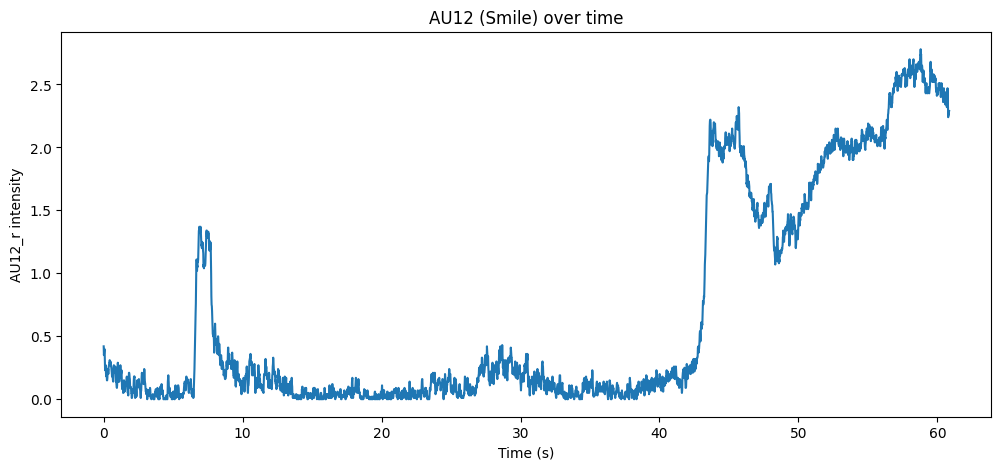

In [8]:
plt.figure(figsize=(12,5))

plt.plot(df["timestamp"], df["AU12_r"])
plt.xlabel("Time (s)")
plt.ylabel("AU12_r intensity")
plt.title("AU12 (Smile) over time")

plt.show()